# Predicting In-Vehicle Coupon Acceptance
**Atharv Deepak Jaiswal · PRN 23070521023 · CA3 Predictive Analytics**

This project follows Knowledge Discovery in Databases (KDD): selection, preprocessing, transformation, modelling and interpretation. We predict **stated coupon acceptance in a survey**, not observed redemption or purchases. `Y=1` means acceptance. The objective is to compare understandable classifiers and identify useful predictive associations.

Source: [UCI dataset 603](https://archive.ics.uci.edu/dataset/603/in+vehicle+coupon+recommendation), DOI [10.24432/C5GS4P](https://doi.org/10.24432/C5GS4P), CC BY 4.0. Original research: Wang et al. (2017), *A Bayesian Framework for Learning Rule Sets for Interpretable Classification*, JMLR 18(70), 1–37. No causal or production marketing claim is made.

In [1]:
from pathlib import Path
import json, hashlib, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.inspection import permutation_importance
ROOT=Path.cwd()
assert (ROOT/'data/in-vehicle-coupon-recommendation.csv').exists(), 'Run from the project folder.'
for folder in ['results','figures','models']: (ROOT/folder).mkdir(exist_ok=True)
SEED=42
sns.set_theme(style='whitegrid', palette=['#0c7c86','#f2a541'])
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
def savefig(name):
    plt.tight_layout()
    plt.savefig(ROOT/'figures'/name,dpi=180,bbox_inches='tight')
    plt.show()
df=pd.read_csv(ROOT/'data/in-vehicle-coupon-recommendation.csv')
assert df.shape==(12684,26) and set(df.Y)=={0,1}
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'missing_percent':df.isna().mean()*100,'unique_nonmissing':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(ROOT/'results/data_audit.csv')


mkdir -p failed for path C:\Users\atharv.j\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\atharv.j\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\atharv.j\AppData\Local\Temp\matplotlib-hevp1uia because there was an issue with the default path (C:\Users\atharv.j\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,dtype,missing,missing_percent,unique_nonmissing
destination,str,0,0.000000,3
passanger,str,0,0.000000,4
weather,str,0,0.000000,3
temperature,int64,0,0.000000,3
time,str,0,0.000000,5
coupon,str,0,0.000000,5
expiration,str,0,0.000000,2
gender,str,0,0.000000,2
age,str,0,0.000000,8
maritalStatus,str,0,0.000000,5


Exact duplicate rows: 74


## 1. Selection and leakage-aware holdout
The original data is preserved, including duplicate observations. Identical predictor profiles are grouped before splitting, so repeated scenarios cannot cross partitions. The first fold of a shuffled five-fold stratified-group split gives an approximately 80/20 holdout; it is selected without inspecting model results. Respondent identifiers are absent, so this does not guarantee separation of people. Exploratory analysis uses training data only.

train_rows               10148.000000
test_rows                 2536.000000
train_acceptance_rate        0.568388
test_acceptance_rate         0.568612
predictor_groups         12587.000000
shared_groups                0.000000
dtype: float64

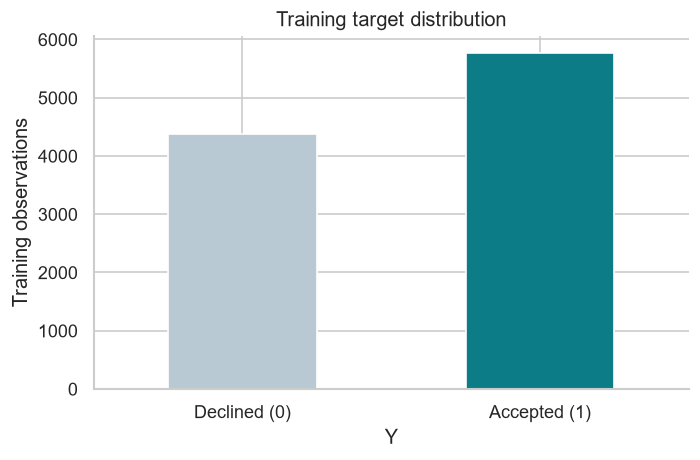

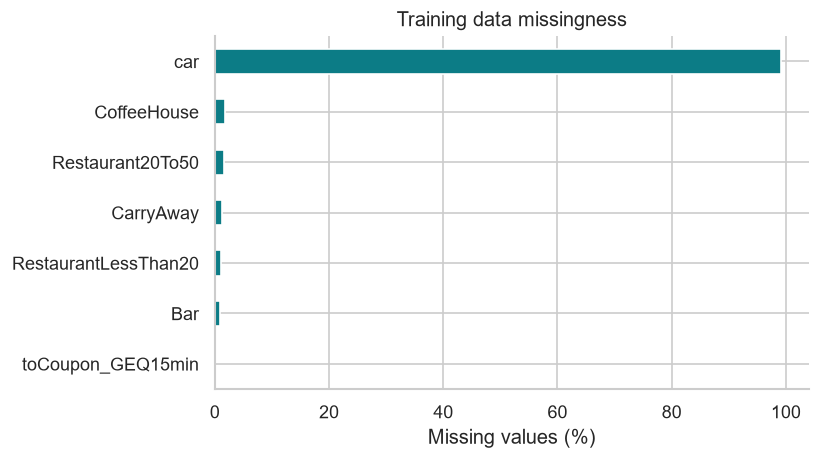

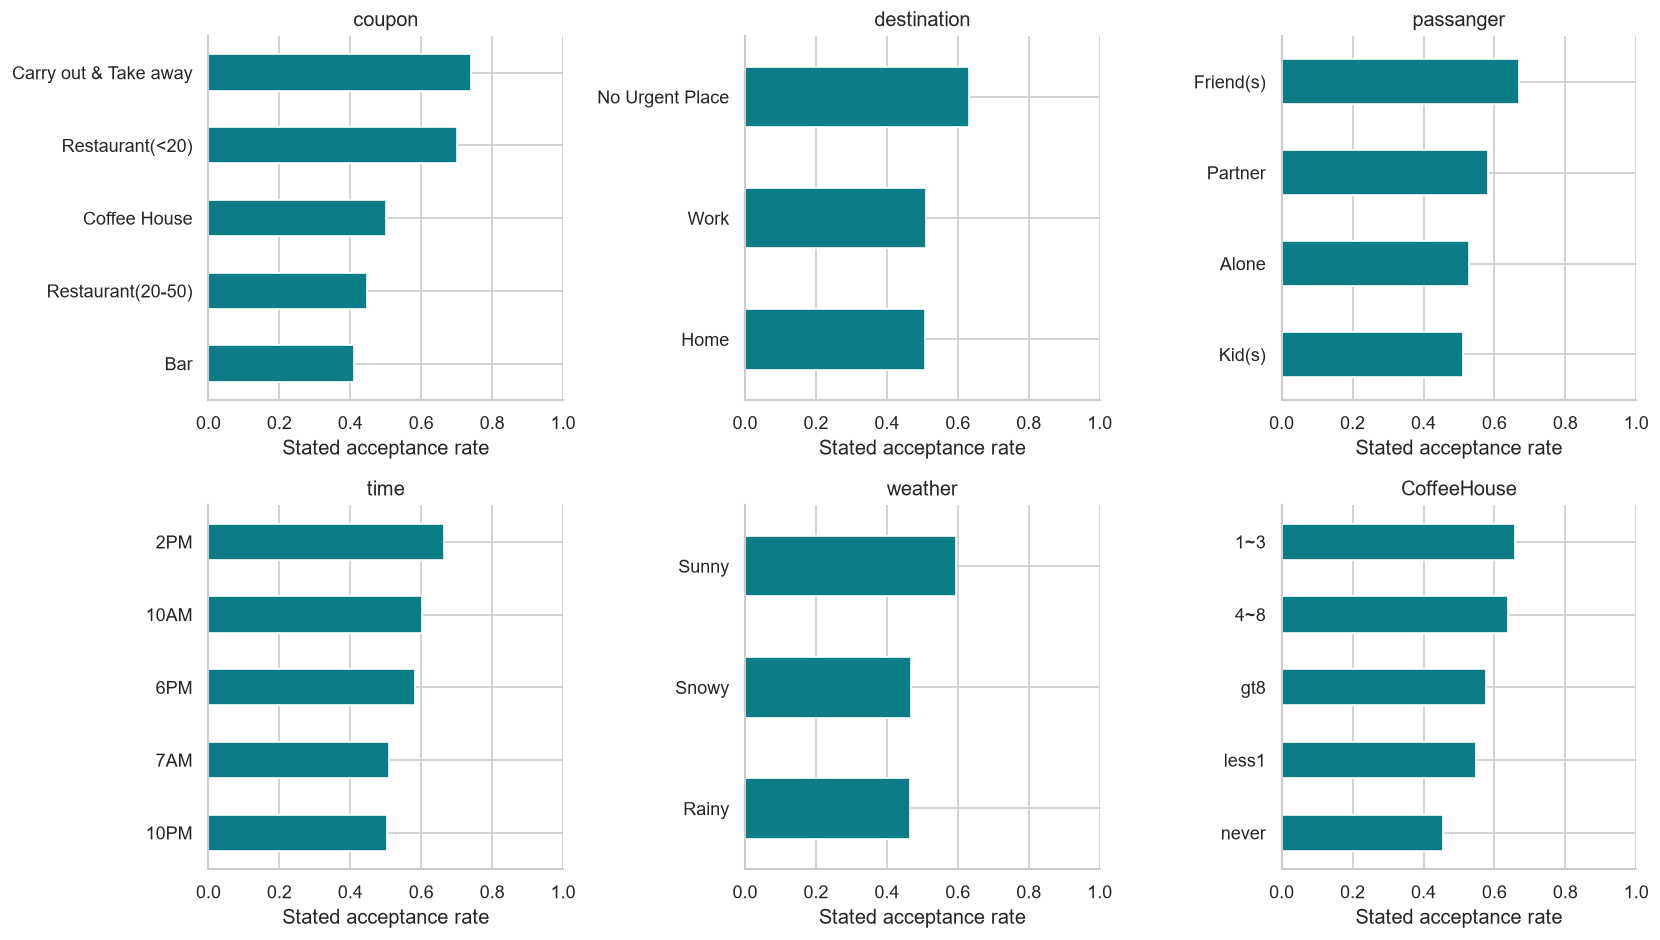

In [2]:
X=df.drop(columns='Y'); y=df.Y
groups=pd.util.hash_pandas_object(X,index=False).astype(str)
train_idx,test_idx=next(StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(X,y,groups))
X_train=X.iloc[train_idx].copy(); X_test=X.iloc[test_idx].copy()
y_train=y.iloc[train_idx]; y_test=y.iloc[test_idx]; g_train=groups.iloc[train_idx]
assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx]))
pd.DataFrame({'original_row':np.arange(len(df)),'partition':np.where(np.isin(np.arange(len(df)),test_idx),'test','train'),'profile_group':groups}).to_csv(ROOT/'results/split_manifest.csv',index=False)
split={'train_rows':len(train_idx),'test_rows':len(test_idx),'train_acceptance_rate':float(y_train.mean()),'test_acceptance_rate':float(y_test.mean()),'predictor_groups':int(groups.nunique()),'shared_groups':0}
display(pd.Series(split))
train=X_train.assign(Y=y_train)
fig,ax=plt.subplots(figsize=(6,4)); y_train.value_counts().sort_index().plot.bar(ax=ax,color=['#b9c9d4','#0c7c86'])
ax.set(xticklabels=['Declined (0)','Accepted (1)'],ylabel='Training observations',title='Training target distribution'); ax.tick_params(axis='x',rotation=0); savefig('class_balance.png')
fig,ax=plt.subplots(figsize=(7,4)); (X_train.isna().mean()*100).sort_values().tail(7).plot.barh(ax=ax,color='#0c7c86'); ax.set(xlabel='Missing values (%)',title='Training data missingness'); savefig('missingness.png')
fig,axes=plt.subplots(2,3,figsize=(14,8))
for col,ax in zip(['coupon','destination','passanger','time','weather','CoffeeHouse'],axes.flat):
    train.groupby(col).Y.mean().sort_values().plot.barh(ax=ax,color='#0c7c86')
    ax.set(title=col,xlabel='Stated acceptance rate',ylabel='',xlim=(0,1))
savefig('training_acceptance_patterns.png')
train.groupby('coupon').Y.agg(['size','mean']).to_csv(ROOT/'results/training_coupon_rates.csv')


## 2. Preprocessing and feature representation
Schema decisions use only the training partition: remove columns with over 90% missingness and constant columns. All learned imputation, scaling and encoding are fitted inside each cross-validation fold. Age, income and visit-frequency bands remain categorical; one-hot encoding avoids imposing arbitrary distances between categories. Numeric inputs are median-imputed and standardized. Missing categories receive an explicit `Missing` label. This representation is the feature transformation stage; no unsupported synthetic predictors are added.

The CSV spells passenger as `passanger`; the original name is retained for reproducibility.

In [3]:
dropped={c:('over 90% missing' if X_train[c].isna().mean()>0.9 else 'constant in training') for c in X_train if X_train[c].isna().mean()>0.9 or X_train[c].nunique(dropna=True)<=1}
features=[c for c in X_train if c not in dropped]
numeric=X_train[features].select_dtypes(include='number').columns.tolist()
categorical=[c for c in features if c not in numeric]
preprocessor=ColumnTransformer([
 ('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),numeric),
 ('categorical',Pipeline([('impute',SimpleImputer(strategy='constant',fill_value='Missing')),('encode',OneHotEncoder(handle_unknown='ignore'))]),categorical)
],remainder='drop')
print('Dropped:',dropped); print('Retained features:',len(features))
cv=list(StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(X_train,y_train,g_train))
for a,b in cv: assert set(g_train.iloc[a]).isdisjoint(set(g_train.iloc[b]))


Dropped: {'car': 'over 90% missing', 'toCoupon_GEQ5min': 'constant in training'}
Retained features: 23


## 3. Training and model selection
Compare a majority-class baseline, Logistic Regression, Decision Tree and Random Forest. Five-fold grouped cross-validation uses only the training partition. Select each model's configuration by mean F1 for acceptance; ROC-AUC breaks ties. Select the final algorithm by the same rule. Use a fixed 0.5 classification threshold and no test-set tuning. F1 balances precision and recall but does not specify business costs. The modest class imbalance does not justify automatic resampling.

Majority baseline {'model': 'Majority baseline', 'cv_f1': 0.724805229998082, 'cv_f1_std': 0.00016708973248878272, 'cv_roc_auc': 0.5, 'cv_accuracy': 0.5683878897406748, 'train_f1': 0.7248052276025965, 'best_parameters': {}}


Logistic Regression {'model': 'Logistic Regression', 'cv_f1': 0.7337128175259247, 'cv_f1_std': 0.007054437008080085, 'cv_roc_auc': 0.7344214227069914, 'cv_accuracy': 0.6820062960911766, 'train_f1': 0.7443155360392014, 'best_parameters': {'model__C': 0.1}}


Decision Tree {'model': 'Decision Tree', 'cv_f1': 0.7416691343569247, 'cv_f1_std': 0.006153944985879065, 'cv_roc_auc': 0.6764457777231058, 'cv_accuracy': 0.6373654550577628, 'train_f1': 0.742490210175969, 'best_parameters': {'model__max_depth': 3, 'model__min_samples_leaf': 5}}


Random Forest {'model': 'Random Forest', 'cv_f1': 0.7914336549239769, 'cv_f1_std': 0.006837229597344503, 'cv_roc_auc': 0.8175818129904094, 'cv_accuracy': 0.7491143692735205, 'train_f1': 0.9627697148905815, 'best_parameters': {'model__max_depth': None, 'model__min_samples_leaf': 2}}


,model,cv_f1,cv_f1_std,cv_roc_auc,cv_accuracy,train_f1,best_parameters
3,Random Forest,0.791434,0.006837,0.817582,0.749114,0.962770,"{'model__max_depth': None, 'model__min_samples..."
2,Decision Tree,0.741669,0.006154,0.676446,0.637365,0.742490,"{'model__max_depth': 3, 'model__min_samples_le..."
1,Logistic Regression,0.733713,0.007054,0.734421,0.682006,0.744316,{'model__C': 0.1}
0,Majority baseline,0.724805,0.000167,0.500000,0.568388,0.724805,{}


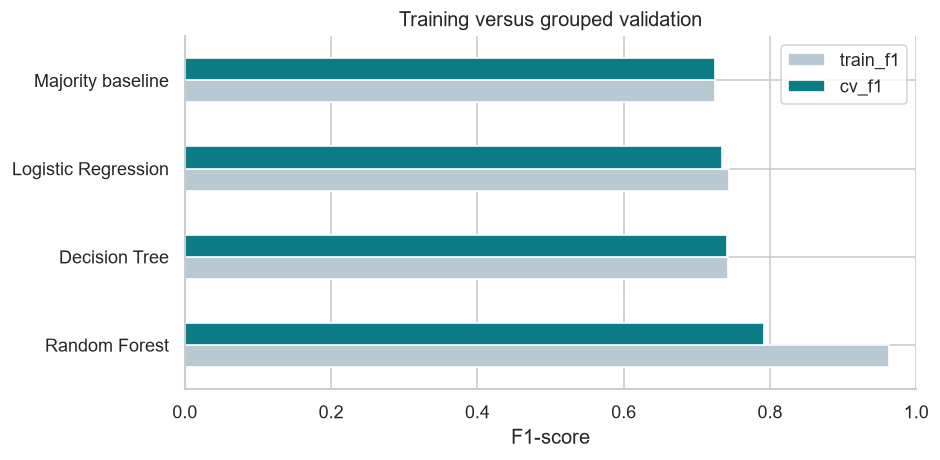

In [4]:
specs={
 'Majority baseline':(DummyClassifier(strategy='most_frequent'),{}),
 'Logistic Regression':(LogisticRegression(max_iter=2000,random_state=SEED),{'model__C':[0.1,1,10]}),
 'Decision Tree':(DecisionTreeClassifier(random_state=SEED),{'model__max_depth':[3,5,10],'model__min_samples_leaf':[5,20]}),
 'Random Forest':(RandomForestClassifier(n_estimators=200,random_state=SEED,n_jobs=2),{'model__max_depth':[10,None],'model__min_samples_leaf':[2,5]})}
def choose_index(r):
    return sorted(range(len(r['mean_test_f1'])),key=lambda i:(r['mean_test_f1'][i],r['mean_test_roc_auc'][i]),reverse=True)[0]
searches={}; rows=[]
for name,(model,grid) in specs.items():
    search=GridSearchCV(Pipeline([('prepare',preprocessor),('model',model)]),grid,scoring={'f1':'f1','roc_auc':'roc_auc','accuracy':'accuracy'},refit=choose_index,cv=cv,n_jobs=1,return_train_score=True,error_score='raise')
    search.fit(X_train,y_train)
    i=search.best_index_; r=search.cv_results_; searches[name]=search
    rows.append({'model':name,'cv_f1':float(r['mean_test_f1'][i]),'cv_f1_std':float(r['std_test_f1'][i]),'cv_roc_auc':float(r['mean_test_roc_auc'][i]),'cv_accuracy':float(r['mean_test_accuracy'][i]),'train_f1':float(r['mean_train_f1'][i]),'best_parameters':search.best_params_})
    print(name,rows[-1],flush=True)
    pd.DataFrame(r).to_csv(ROOT/'results'/('cv_'+name.lower().replace(' ','_')+'.csv'),index=False)
comparison=pd.DataFrame(rows).sort_values(['cv_f1','cv_roc_auc'],ascending=False)
selected_name=comparison.iloc[0]['model']; selected=searches[selected_name].best_estimator_
comparison.to_csv(ROOT/'results/model_comparison.csv',index=False)
display(comparison)
fig,ax=plt.subplots(figsize=(8,4)); comparison.set_index('model')[['train_f1','cv_f1']].plot.barh(ax=ax,color=['#b9c9d4','#0c7c86']); ax.set(xlim=(0,1),xlabel='F1-score',ylabel='',title='Training versus grouped validation'); savefig('model_comparison.png')


## 4. One-time held-out evaluation
The chosen pipeline was refitted on all training observations by the search. Evaluate it and the reference baseline on the untouched test partition. The confusion matrix uses rows = actual and columns = predicted, with declined first. Probability scores are uncalibrated model outputs, not guaranteed real-world probabilities.

,Selected model,Baseline
accuracy,0.766562,0.568612
precision,0.763648,0.568612
recall,0.853675,1.000000
f1,0.806156,0.724987
roc_auc,0.836627,0.500000


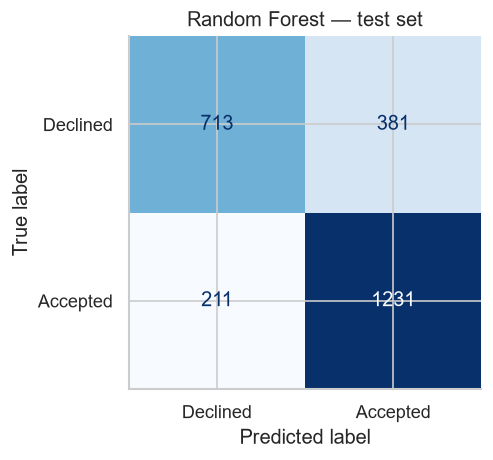

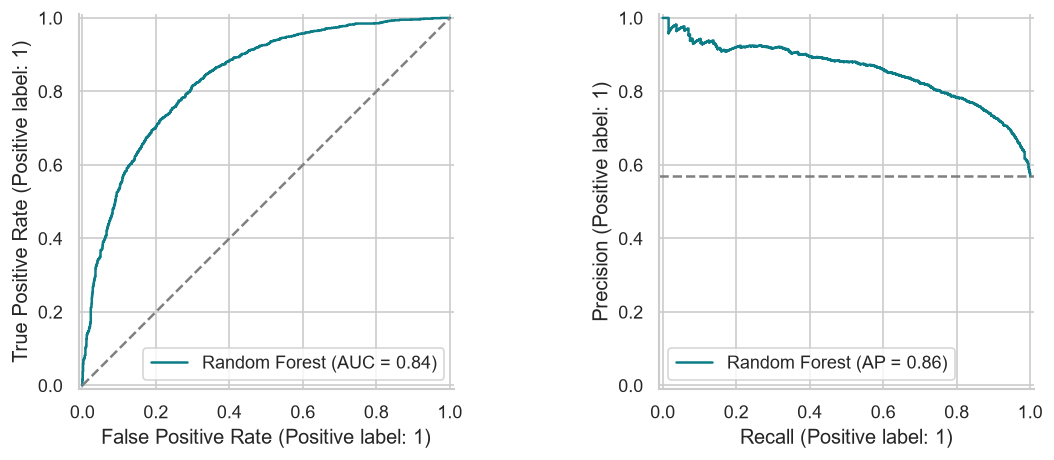

In [5]:
pred=selected.predict(X_test); prob=selected.predict_proba(X_test)[:,1]
def metrics(target,prediction,probability):
    return {'accuracy':accuracy_score(target,prediction),'precision':precision_score(target,prediction,zero_division=0),'recall':recall_score(target,prediction),'f1':f1_score(target,prediction),'roc_auc':roc_auc_score(target,probability),'confusion_matrix':confusion_matrix(target,prediction).tolist()}
test_metrics=metrics(y_test,pred,prob)
baseline=searches['Majority baseline'].best_estimator_
baseline_metrics=metrics(y_test,baseline.predict(X_test),baseline.predict_proba(X_test)[:,1])
summary={'title':'Predicting In-Vehicle Coupon Acceptance','dataset':{'rows':len(df),'features':25,'exact_duplicate_rows':int(df.duplicated().sum()),'acceptance_rate':float(y.mean()),'source':'https://doi.org/10.24432/C5GS4P','license':'CC BY 4.0','sha256':hashlib.sha256((ROOT/'data/in-vehicle-coupon-recommendation.csv').read_bytes()).hexdigest()},'split':split,'dropped_columns':dropped,'retained_features':len(features),'selected_model':selected_name,'best_parameters':searches[selected_name].best_params_,'cv_results':rows,'test_metrics':test_metrics,'baseline_test_metrics':baseline_metrics,'limitations':['Survey intention is not observed purchase or redemption.','Respondent IDs are unavailable; identical-profile grouping does not guarantee independent people.','No external or temporal validation; no causal interpretation.','Probabilities are uncalibrated; demographic inputs require review before practical use.'],'checks':{'holdout_group_overlap':0,'cv_group_overlap':0,'target_excluded':True}}
(ROOT/'results/summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
display(pd.DataFrame({'Selected model':{k:v for k,v in test_metrics.items() if k!='confusion_matrix'},'Baseline':{k:v for k,v in baseline_metrics.items() if k!='confusion_matrix'}}))
fig,ax=plt.subplots(figsize=(5,4)); ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=['Declined','Accepted'],ax=ax,cmap='Blues',colorbar=False); ax.set_title(selected_name+' — test set'); savefig('confusion_matrix.png')
fig,axes=plt.subplots(1,2,figsize=(10,4)); RocCurveDisplay.from_predictions(y_test,prob,ax=axes[0],name=selected_name); axes[0].plot([0,1],[0,1],'--',color='gray'); PrecisionRecallDisplay.from_predictions(y_test,prob,ax=axes[1],name=selected_name); axes[1].axhline(y_test.mean(),linestyle='--',color='gray'); savefig('roc_precision_recall.png')
pd.DataFrame({'original_row':test_idx,'actual':y_test.to_numpy(),'predicted':pred,'acceptance_probability':prob,'coupon':X_test.coupon.to_numpy()}).to_csv(ROOT/'results/test_predictions.csv',index=False)


## 5. Interpretation, errors and example predictions
Permutation importance measures the drop in test F1 after shuffling one original input column (five repeats). It is descriptive analysis after model selection and is not used for tuning. Correlated variables may share or mask importance. Error rates by coupon category are descriptive, with sample counts supplied. Hypothetical scenarios below use a typical training profile with explicit changes; they are demonstrations, not observed outcomes.

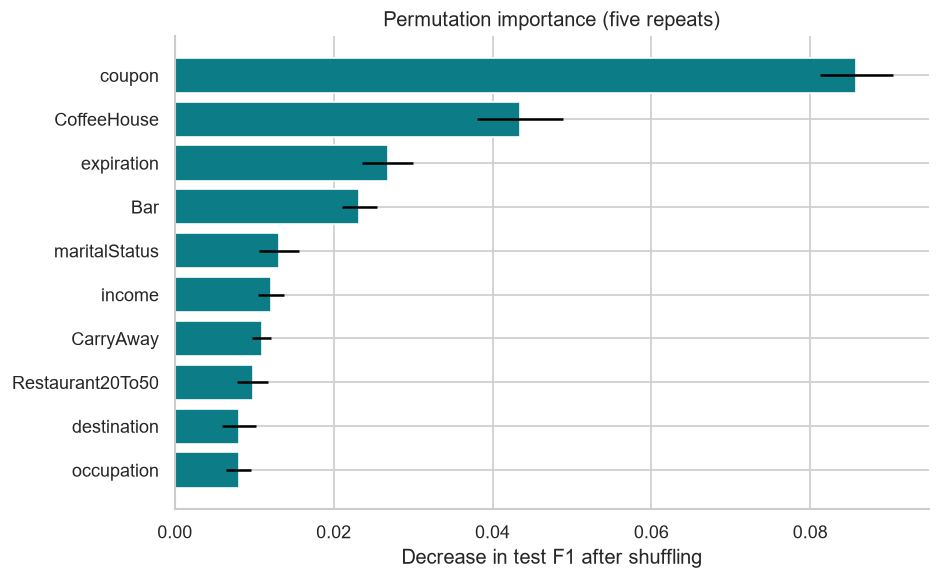

,count,error_rate,actual_acceptance,predicted_acceptance
coupon,,,,
Bar,408,0.218137,0.411765,0.370098
Carry out & Take away,489,0.243354,0.719836,0.938650
Coffee House,788,0.220812,0.492386,0.494924
Restaurant(20-50),282,0.343972,0.418440,0.457447
Restaurant(<20),569,0.198594,0.731107,0.848858


,coupon,destination,predicted_acceptance,model_probability
0,Coffee House,No Urgent Place,1,0.647450
1,Bar,Work,0,0.293670
2,Carry out & Take away,Home,1,0.788556


All validation checks passed. Selected: Random Forest


In [6]:
importance=permutation_importance(selected,X_test,y_test,scoring='f1',n_repeats=5,random_state=SEED,n_jobs=1)
imp=pd.DataFrame({'feature':X_test.columns,'mean_f1_decrease':importance.importances_mean,'std':importance.importances_std}).sort_values('mean_f1_decrease',ascending=False)
imp.to_csv(ROOT/'results/permutation_importance.csv',index=False)
fig,ax=plt.subplots(figsize=(8,5)); top=imp.head(10).sort_values('mean_f1_decrease'); ax.barh(top.feature,top.mean_f1_decrease,xerr=top['std'],color='#0c7c86'); ax.set(xlabel='Decrease in test F1 after shuffling',title='Permutation importance (five repeats)'); savefig('feature_importance.png')
errors=pd.DataFrame({'coupon':X_test.coupon.to_numpy(),'wrong':pred!=y_test.to_numpy(),'actual':y_test.to_numpy(),'predicted':pred}).groupby('coupon').agg(count=('wrong','size'),error_rate=('wrong','mean'),actual_acceptance=('actual','mean'),predicted_acceptance=('predicted','mean'))
errors.to_csv(ROOT/'results/errors_by_coupon.csv'); display(errors)
examples=pd.DataFrame([X_train.mode(dropna=True).iloc[0].to_dict() for _ in range(3)])
examples.loc[0,['coupon','destination','CoffeeHouse']]=['Coffee House','No Urgent Place','gt8']
examples.loc[1,['coupon','destination','Bar']]=['Bar','Work','never']
examples.loc[2,['coupon','destination','expiration']]=['Carry out & Take away','Home','1d']
example_predictions=examples.copy(); example_predictions['predicted_acceptance']=selected.predict(examples); example_predictions['model_probability']=selected.predict_proba(examples)[:,1]
example_predictions.to_csv(ROOT/'results/hypothetical_predictions.csv',index=False)
display(example_predictions[['coupon','destination','predicted_acceptance','model_probability']])
joblib.dump(selected,ROOT/'models/coupon_acceptance_pipeline.joblib',compress=3)
restored=joblib.load(ROOT/'models/coupon_acceptance_pipeline.joblib')
assert np.allclose(restored.predict_proba(X_test),selected.predict_proba(X_test))
edge=examples.iloc[[0]].copy(); edge.loc[edge.index[0],'occupation']='Unseen occupation'; edge.loc[edge.index[0],'CoffeeHouse']=np.nan; edge.loc[edge.index[0],'temperature']=np.nan
assert np.isfinite(restored.predict_proba(edge)).all()
summary['top_features']=imp.head(10).to_dict(orient='records')
summary['errors_by_coupon']=errors.reset_index().to_dict(orient='records')
summary['hypothetical_predictions']=example_predictions[['coupon','destination','predicted_acceptance','model_probability']].to_dict(orient='records')
summary['checks'].update({'reload_predictions_match':True,'missing_and_unseen_values_supported':True,'notebook_completed':True})
summary['versions']={p:importlib.metadata.version(p) for p in ['numpy','pandas','scikit-learn','matplotlib','seaborn','joblib','nbformat','nbclient','ipykernel']}
summary['python']=platform.python_version()
(ROOT/'results/summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print('All validation checks passed. Selected:',selected_name)


## 6. Conclusions and responsible interpretation
Read the executed comparison and test results above: the selected model is chosen using grouped validation, not the holdout. Compare its F1 and ROC-AUC against the majority baseline, and examine the training–validation gap before describing generalization. Strong performance on this split does not establish future effectiveness.

The study is limited by survey intentions, unknown respondent identities, possible shared respondent patterns, and lack of external or temporal validation. Feature importance indicates model dependence rather than causal effects. Future work should obtain respondent IDs and actual redemptions, assess calibration and subgroup performance, and evaluate on a separate population before any business use.

### References
1. UCI Machine Learning Repository. (2017). *In-Vehicle Coupon Recommendation*. https://doi.org/10.24432/C5GS4P. CC BY 4.0.
2. Wang, T., Rudin, C., Doshi-Velez, F., Liu, Y., Klampfl, E., & MacNeille, P. (2017). A Bayesian Framework for Learning Rule Sets for Interpretable Classification. *JMLR, 18*(70), 1–37. https://jmlr.org/papers/v18/16-003.html
3. Scikit-learn documentation. *Common pitfalls and recommended practices*. https://scikit-learn.org/stable/common_pitfalls.html
4. Scikit-learn documentation. *Permutation feature importance*. https://scikit-learn.org/stable/modules/permutation_importance.html
